# Снижение размерности — PCA, t-SNE и UMAP

In [1]:
# Загрузка и первичный анализ данных

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

digits = load_digits()

print(digits.keys())
X = digits.data
y = digits.target

print(f"Форма X: {X.shape}")
print(f"Классы: {np.unique(y)}")
print(f"Признаки: {X.shape[1]} (8x8 пикселей)")

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Форма X: (1797, 64)
Классы: [0 1 2 3 4 5 6 7 8 9]
Признаки: 64 (8x8 пикселей)


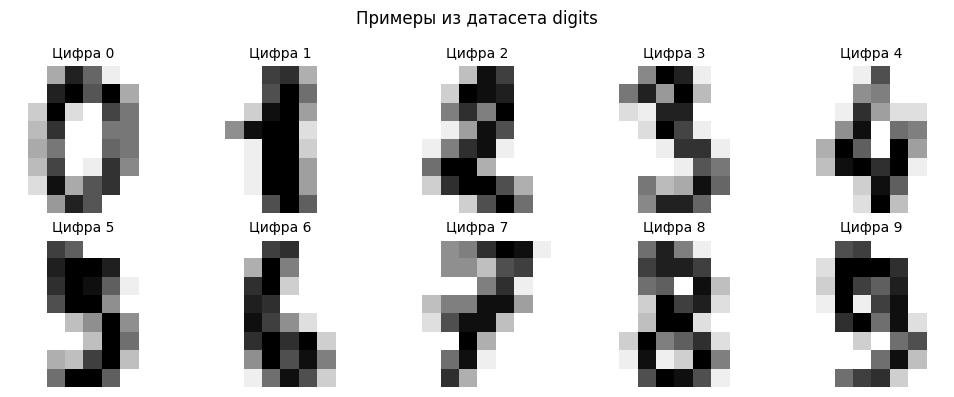

In [2]:
# Визуализация примеры из каждого класса
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    sample_idx = np.where(y == idx)[0][0]
    ax.imshow(X[sample_idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Цифра {idx}', fontsize=10)
    ax.axis('off')
plt.suptitle('Примеры из датасета digits', fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Среднее до: {X.mean():.2f}, после: {X_scaled.mean():.4f}")
print(f"Std до: {X.std():.2f}, после: {X_scaled.std():.4f}")

Среднее до: 4.88, после: 0.0000
Std до: 6.02, после: 0.9763


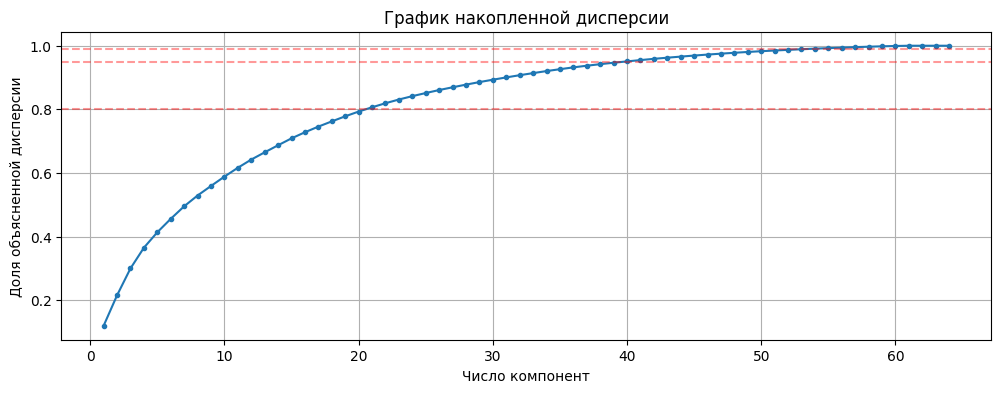

80% дисперсии -> 21 компонент
95% дисперсии -> 40 компонент
99% дисперсии -> 54 компонент


In [4]:
# PCA: explained variance и выбор числа компонент

pca_full = PCA(n_components= 64, random_state= 42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize= (12, 4))
plt.plot(range(1, 65), cumvar, marker = '.')
for threshold in [0.80, 0.95, 0.99]:
    plt.axhline(y = threshold, linestyle = '--', color = 'r', alpha = 0.4)

plt.xlabel('Число компонент')
plt.ylabel('Доля объясненной дисперсии')
plt.title('График накопленной дисперсии')
plt.grid(True)
plt.show()


for threshold in [0.80, 0.95, 0.99]:
    for i in range(1, 65):
        if cumvar[i-1] >=threshold:
            k= i  
            break
    print(f"{int(threshold*100)}% дисперсии -> {k} компонент")

PC1: 12.0%
PC2: 9.6%
Итого: 21.6%


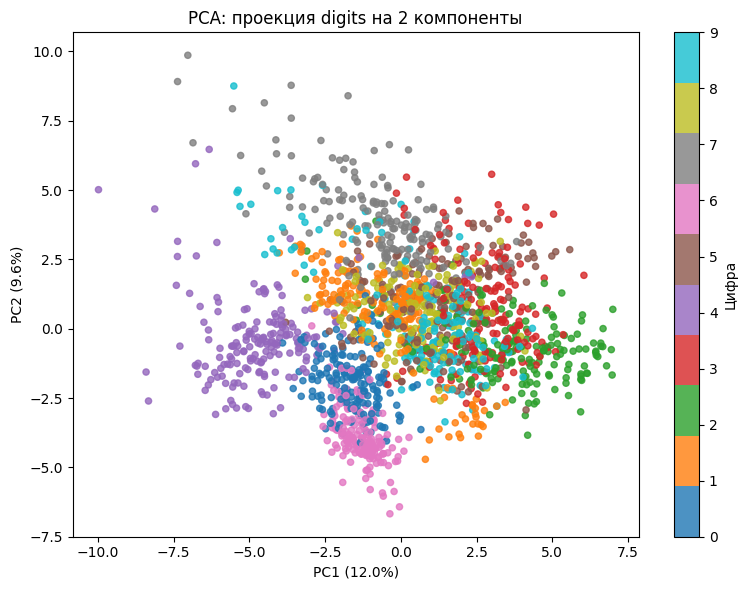

In [5]:
# PCA для визуализации (2 компоненты)
pca2 = PCA(n_components= 2, random_state= 42)
X_pca2 = pca2.fit_transform(X_scaled)

print(f"PC1: {pca2.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca2.explained_variance_ratio_[1]*100:.1f}%")
print(f"Итого: {pca2.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c = y, cmap= 'tab10', s = 20, alpha = 0.8)
plt.colorbar(scatter, label='Цифра')

plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: проекция digits на 2 компоненты')
plt.tight_layout()
plt.show()


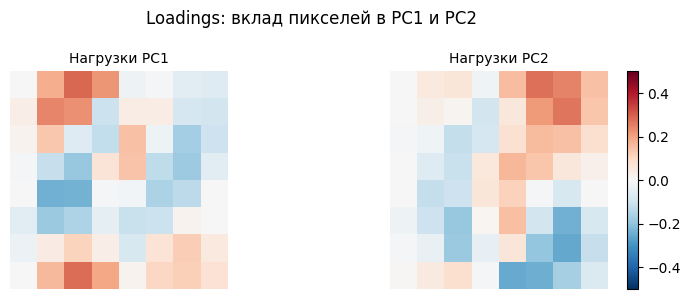

In [6]:
# Интерпретация: loadings (нагрузки)
fig, axes = plt.subplots(1, 2, figsize = (8, 3))

for i, ax in enumerate(axes):
    comp_data = pca2.components_[i].reshape(8, 8)
    im = ax.imshow(comp_data, cmap = 'RdBu_r', vmin= -0.5, vmax = 0.5)
    ax.set_title(f'Нагрузки PC{i+1}', fontsize=10)
    ax.axis('off')

plt.colorbar(im)
plt.suptitle('Loadings: вклад пикселей в PC1 и PC2', fontsize=12)
plt.tight_layout()
plt.show()

Выявлена низкая информативность центральной зоны изображения, что обусловлено высокой стабильностью данных пикселей во всей выборке. Основная объяснимая дисперсия сосредоточена на периферии: PC1 имеет основную дисперсию по всей левой стороне, фиксируя общие различия классов в других местах, но менее значительно. PC2 демонстрирует выраженную биполярность в правой части кадра, противопоставляя верхний и нижний правые части, что позволяет идентифицировать специфические изгибы и терминальные элементы цифр.

In [7]:
# PCA как препроцессинг для классификатора

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size= 0.2, random_state= 42 
)

results = {}

# --- Вариант 1: без PCA ---
clf_base = LogisticRegression(max_iter= 1000, random_state= 42)
clf_base.fit(X_train, y_train)
clf_pred = clf_base.predict(X_test)
clf_result = accuracy_score(y_test, clf_pred)

results['Без PCA (64 признака)'] = clf_result

# --- Вариант 2: PCA с 95% дисперсии ---
pca_95 = PCA(n_components= 0.95, random_state= 42)
X_train_95 = pca_95.fit_transform(X_train)
X_test_95 = pca_95.transform(X_test)

clf_95 = LogisticRegression(max_iter= 1000, random_state= 42)
clf_95.fit(X_train_95, y_train)
clf_95_pred = clf_95.predict(X_test_95)
clf_95_result = accuracy_score(y_test, clf_95_pred)

results[f'PCA 95% ({pca_95.n_components_} компонент)'] = clf_95_result

# --- Вариант 3: PCA с 80% дисперсии ---
pca_80 = PCA(n_components= 0.8, random_state= 42)
X_train_80 = pca_80.fit_transform(X_train)
X_test_80 = pca_80.transform(X_test)

clf_80 = LogisticRegression(max_iter= 1000, random_state= 42)
clf_80.fit(X_train_80, y_train)
clf_80_pred = clf_80.predict(X_test_80)
clf_80_result = accuracy_score(y_test, clf_80_pred)

results[f'PCA 80% ({pca_80.n_components_} компонент)'] = clf_80_result

print('Сравнение accuracy')
print("-" * 45)
for name, acc in results.items():
    print(f"{name:35s}: {acc:.4f}")


Сравнение accuracy
---------------------------------------------
Без PCA (64 признака)              : 0.9722
PCA 95% (40 компонент)             : 0.9639
PCA 80% (21 компонент)             : 0.9472


После PCA(30): 30.0% дисперсии


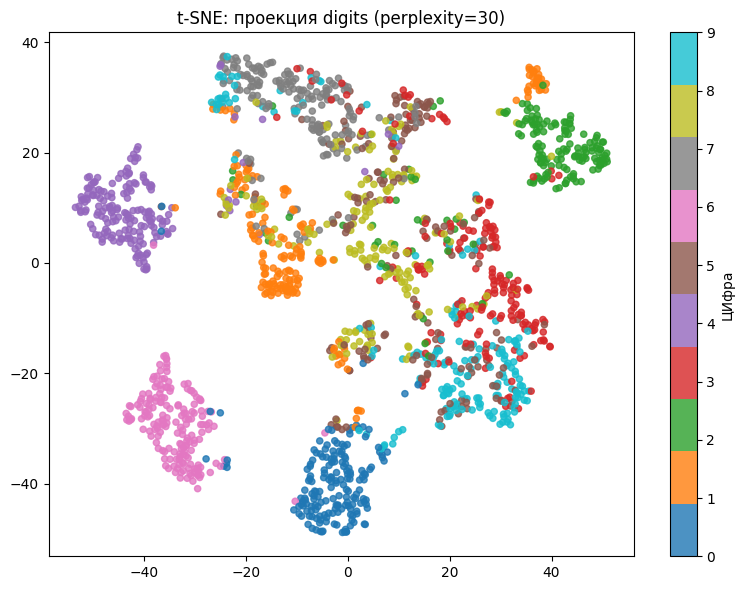

In [8]:
# t-SNE: нелинейная визуализация

pca_30 = PCA(n_components= 0.3, random_state= 42)
X_pca_30 = pca_30.fit_transform(X_scaled)
print(f'После PCA(30): {pca_30.explained_variance_ratio_.sum()*100:.1f}% дисперсии')

tsne = TSNE(n_components= 2, perplexity= 30, max_iter= 1000, random_state= 42)
X_tsne = tsne.fit_transform(X_pca_30)

plt.figure(figsize= (8, 6))
scatter_1 = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c = y, cmap= 'tab10', s = 20, alpha = 0.8)
plt.colorbar(scatter_1, label = 'ЦИфра')
plt.title('t-SNE: проекция digits (perplexity=30)')
plt.tight_layout()
plt.show()

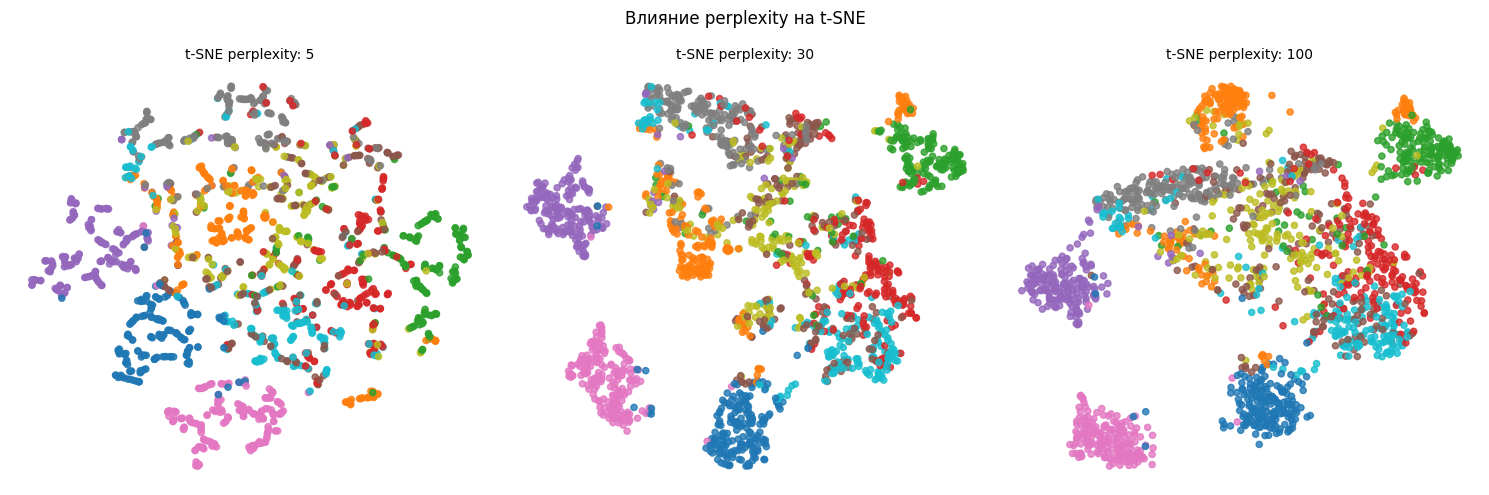

In [9]:
# Эксперимент с perplexity: 5, 30, 100

fig, axes = plt.subplots(1, 3, figsize = (15, 5))

for ax, perp in zip(axes, [5, 30, 100]):
    tsne_p = TSNE(n_components= 2, perplexity= perp, max_iter= 1000, random_state= 42)
    X_tsne_p = tsne_p.fit_transform(X_pca_30)
    ax.scatter(X_tsne_p[:, 0], X_tsne_p[:, 1], c = y, cmap = 'tab10', s = 20, alpha = 0.8)
    ax.set_title(f't-SNE perplexity: {perp}', fontsize = 10)
    ax.axis('off')

plt.suptitle('Влияние perplexity на t-SNE', fontsize=12)
plt.tight_layout()
plt.show()

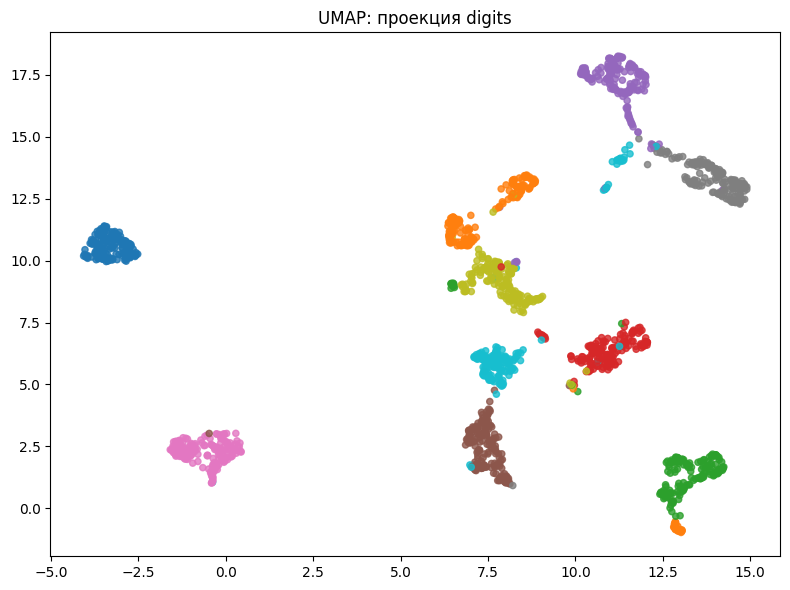

In [10]:
# UMAP

import umap

reducer = umap.UMAP(n_neighbors= 15, min_dist= 0.1, random_state= 42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c = y, cmap = 'tab10', s = 20, alpha = 0.8)
plt.title('UMAP: проекция digits')
plt.tight_layout()
plt.show()

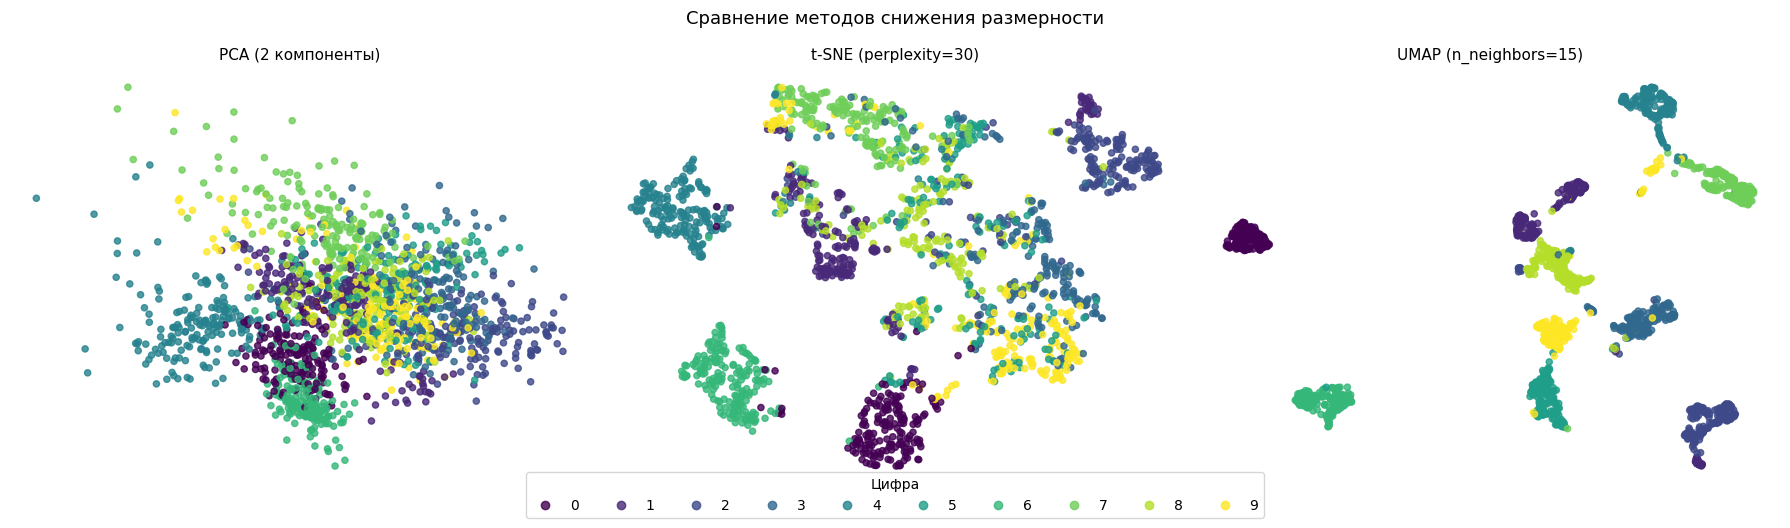

In [14]:
# Сравнение проекций: PCA vs t-SNE vs UMAP

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

projection = [
    (X_pca2, 'PCA (2 компоненты)'),
    (X_tsne, 't-SNE (perplexity=30)'),
    (X_umap, 'UMAP (n_neighbors=15)')
]

for ax, (X_proj, title) in zip(axes, projection):
    scatter = ax.scatter(X_proj[:, 0], X_proj[:, 1], c = y, s = 20, alpha = 0.8)
    ax.set_title(title, fontsize = (11))
    ax.axis('off')

handles, _ = scatter.legend_elements()
fig.legend(handles, [str(i) for i in range(10)],
           loc = 'lower center', ncol = 10, title = 'Цифра',
           bbox_to_anchor=(0.5, -0.05))


plt.suptitle('Сравнение методов снижения размерности', fontsize=13)
plt.tight_layout()
plt.show()


In [16]:
# Количественная оценка: Silhouette Score

from sklearn.metrics import silhouette_score


scores = {}
scores['PCA (2 компоненты)'] = silhouette_score(X_pca2, y)
scores['t-SNE'] = silhouette_score(X_tsne, y)
scores['UMAP'] = silhouette_score(X_umap, y)

print("Silhouette Score (выше = лучше):")
print("-" * 35)
for name, score in sorted(scores.items(), key= lambda x: -x[1]):
    print(f"{name:25s}: {score:.4f}")

Silhouette Score (выше = лучше):
-----------------------------------
UMAP                     : 0.5687
t-SNE                    : 0.2332
PCA (2 компоненты)       : 0.0547


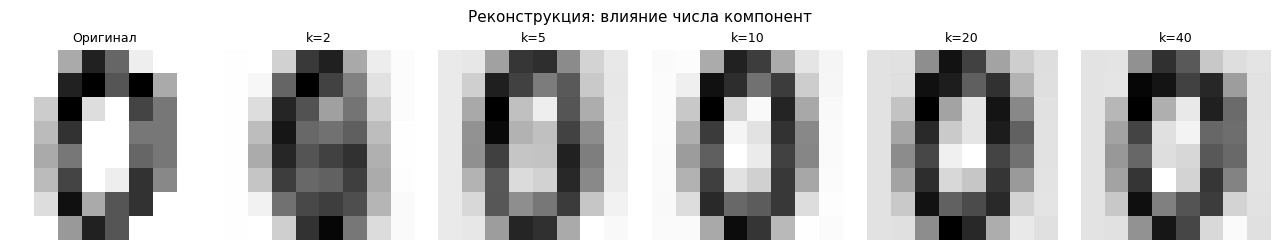

In [17]:
# Реконструкция из PCA

sample_idx = 0
x_original = X_scaled[sample_idx:sample_idx+1]

fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))

x_orig_raw = scaler.inverse_transform(x_original)
axes[0].imshow(x_orig_raw.reshape(8, 8), cmap='gray_r')
axes[0].set_title('Оригинал', fontsize=9)
axes[0].axis('off')

for ax, k in zip(axes[1:], [2, 5, 10, 20, 40]):
    pca_k = PCA(n_components=k, random_state=42)
    pca_k.fit(X_scaled)

    x_proj = pca_k.transform(x_original)

    x_rec = pca_k.inverse_transform(x_proj)

    x_raw = scaler.inverse_transform(x_rec)
    
    ax.imshow(x_raw.reshape(8, 8), cmap='gray_r')
    ax.set_title(f'k={k}', fontsize=9)
    ax.axis('off')

plt.suptitle('Реконструкция: влияние числа компонент', fontsize=11)
plt.tight_layout()
plt.show()


---
## Выводы

**1. Число компонент PCA:**
- Для сохранения 80% дисперсии нужно 21 компонента из 64.
- Для сохранения 95% дисперсии нужно 40 компонент из 64.

**2. PCA как препроцессинг:**
- Accuracy без PCA: 0.9722
- Accuracy с PCA (95%): 0.9639
- Accuracy с PCA (80%): 0.9472
- Вывод: PCA помогает существенно снизить размерность данных и ускорить вычисления (сокращая признаки с 64 до 40 в случае 95%), при этом сохраняя высокую точность классификации за счет удаления избыточных пикселей и шума. Однако чрезмерное сжатие до 80% уже ведет к потере важных нелинейных деталей начертания, из-за чего точность классификатора начинает снижаться.

**3. Сравнение проекций:**
- Лучший Silhouette Score: 0.5687 (метод: UMAP)
- Цифры, которые сложнее всего разделить: 3, 8, 9 (они сильнее всего пересекаются на линейной проекции PCA)

**4. Вывод о методах:**
PCA следует применять в качестве обязательного этапа предварительной обработки данных для фильтрации шума, устранения мультиколлинеарности пикселей и ускорения обучения последующих моделей машинного обучения.
t-SNE и UMAP необходимо использовать для разведочного анализа и визуализации многомерных структур данных. При этом UMAP является более предпочтительным выбором из-за высокой скорости работы, возможности обработки новых тестовых выборок через метод .transform() и точного сохранения не только локального соседства точек, но и глобального расстояния между кластерами.